<a href="https://colab.research.google.com/github/siddhartha121973/2400101530141-B10-python/blob/main/C_AND_D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
!pip install kaggle

In [ ]:
!pip install opendatasets

In [ ]:
!kaggle datasets list -s dogs-vs-cats


You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication


In [ ]:
!kaggle datasets download -d dhirensk/cats-vs-dogs-training8000test2000


Dataset URL: https://www.kaggle.com/datasets/dhirensk/cats-vs-dogs-training8000test2000
License(s): unknown
100% 436M/436M [00:03<00:00, 119MB/s]



In [ ]:
!unzip cats-vs-dogs-training8000test2000.zip -d /content/dataset

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/dataset/training_set/cats/cat.37.jpg  
  inflating: /content/dataset/dataset/training_set/cats/cat.370.jpg  
  inflating: /content/dataset/dataset/training_set/cats/cat.3700.jpg  
  inflating: /content/dataset/dataset/training_set/cats/cat.3701.jpg  
  inflating: /content/dataset/dataset/training_set/cats/cat.3702.jpg  
  inflating: /content/dataset/dataset/training_set/cats/cat.3703.jpg  
  inflating: /content/dataset/dataset/training_set/cats/cat.3704.jpg  
  inflating: /content/dataset/dataset/training_set/cats/cat.3705.jpg  
  inflating: /content/dataset/dataset/training_set/cats/cat.3706.jpg  
  inflating: /content/dataset/dataset/training_set/cats/cat.3707.jpg  
  inflating: /content/dataset/dataset/training_set/cats/cat.3708.jpg  
  inflating: /content/dataset/dataset/training_set/cats/cat.3709.jpg  
  inflating: /content/dataset/dataset/training_set/cats/cat.371.jpg  
  inflating: /content/dataset/

In [ ]:
!ls /content/dataset

dataset


In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout

In [ ]:
train_ds = keras.utils.image_dataset_from_directory(
    directory='/content/dataset/dataset/training_set',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256, 256)
)
validation_ds = keras.utils.image_dataset_from_directory(
    directory='/content/dataset/dataset/test_set',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256, 256)
)

Found 8000 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.


In [ ]:
def process(image, label):
    image = tf.cast(image / 255., tf.float32)
    return image, label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [ ]:
model = Sequential()


model.add(Conv2D(32, kernel_size=(3, 3), padding='valid', activation='relu', input_shape=(256, 256, 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))


model.add(Conv2D(64, kernel_size=(3, 3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))


model.add(Conv2D(128, kernel_size=(3, 3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))
model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
history = model.fit(train_ds, epochs=10, validation_data=validation_ds)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 43s 119ms/step - accuracy: 0.5484 - loss: 1.6494 - val_accuracy: 0.5065 - val_loss: 1.0453
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 23s 91ms/step - accuracy: 0.5924 - loss: 0.7084 - val_accuracy: 0.5500 - val_loss: 0.6959
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 24s 97ms/step - accuracy: 0.6021 - loss: 0.7012 - val_accuracy: 0.5605 - val_loss: 0.6794
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 24s 96ms/step - accuracy: 0.6579 - loss: 0.6201 - val_accuracy: 0.6765 - val_loss: 0.6034
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 23s 91ms/step - accuracy: 0.7054 - loss: 0.5781 - val_accuracy: 0.6430 - val_loss: 0.6258
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 42s 93ms/step - accuracy: 0.7355 - loss: 0.5398 - val_accuracy: 0.6770 - val_loss: 0.6459
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 24s 97ms/step - accuracy: 0.7541 - loss: 0.5192 - val_accuracy: 0.6600 - val_loss: 0.6771
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 39s 91ms/step - accuracy: 0.7797 - loss: 0.4814 -

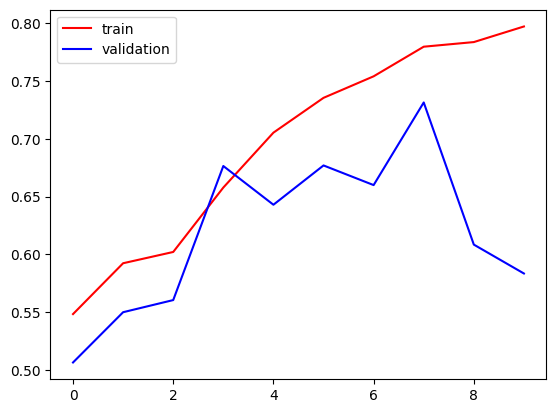

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt.legend()
plt.show()

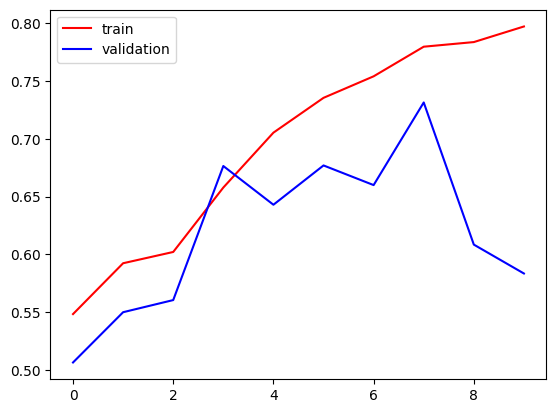

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt.legend()
plt.show()

In [ ]:
import cv2

In [ ]:
test_img = cv2.imread('/content/Screenshot (19).png')

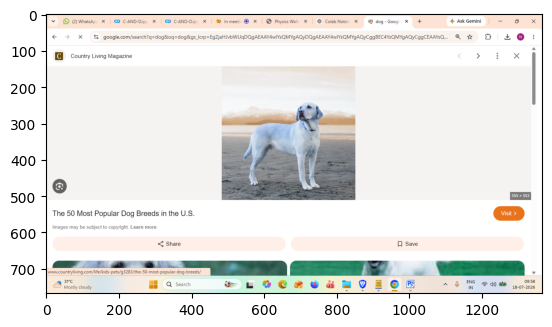

In [ ]:
plt.imshow(test_img)

In [ ]:
test_img.shape

(768, 1366, 3)

In [ ]:
test_img=cv2.resize(test_img,(256,256))

In [ ]:
test_input=test_img.reshape((1,256,256,3))

In [ ]:
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


array([[0.22410858]], dtype=float32)